<a href="https://colab.research.google.com/github/lgb201020/brain_tumor_segmentation_Unet/blob/main/hw4_VGG19%EA%B8%B0%EB%B0%98_Unet_%EB%AA%A8%EB%8D%B8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [27]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [28]:
import os
import time
import copy
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageEnhance

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Optimizer
from torch.utils.data import Dataset, DataLoader, ConcatDataset
from torchvision import transforms
import torchvision.transforms.functional as TF
from torchvision.transforms import InterpolationMode
import torchvision.models as models

In [29]:
!pip install -q monai
from monai.losses import DiceLoss, TverskyLoss

In [30]:
# =========================================================
# 1. Seed / Device
# =========================================================
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

device: cuda


In [31]:
# =========================================================
# 2. Path
# =========================================================
data_dir = "/content/drive/MyDrive/Colab Notebooks/3-2 deep-learning/hw4_data"

train_dir = os.path.join(data_dir, "train")
val_dir = os.path.join(data_dir, "val")
test_dir = os.path.join(data_dir, "test")

save_root = "/content/drive/MyDrive/Colab Notebooks/3-2 deep-learning/hw4_vgg19_dice_bce"
os.makedirs(save_root, exist_ok=True)

print("train_dir:", train_dir)
print("val_dir:", val_dir)
print("test_dir:", test_dir)
print("save_root:", save_root)

train_dir: /content/drive/MyDrive/Colab Notebooks/3-2 deep-learning/hw4_data/train
val_dir: /content/drive/MyDrive/Colab Notebooks/3-2 deep-learning/hw4_data/val
test_dir: /content/drive/MyDrive/Colab Notebooks/3-2 deep-learning/hw4_data/test
save_root: /content/drive/MyDrive/Colab Notebooks/3-2 deep-learning/hw4_vgg19_dice_bce


In [32]:
# =========================================================
# 3. Config
# =========================================================
CFG = {
    "image_size": 224,
    "batch_size": 2,
    "num_workers": 0,
    "num_epochs": 15,
    "lr": 1e-3,
    "weight_decay": 1e-3,
    "threshold": 0.5,
    "use_centercrop": False,
    "crop_size": 224,
    "use_lookahead": False,
    "use_concat_aug4": False,
    "save_predictions": True,
    "prediction_dir_name": "pred_vgg19_dice_bce"
}

In [33]:
# =========================================================
# 4. Augmentation
# =========================================================
class RandomFlipRotateSaturation:
    def __init__(
        self,
        horizontal=False,
        vertical=False,
        rotate_degrees=0,
        saturation_range=(1.0, 1.0),
        p=0.5
    ):
        self.horizontal = horizontal
        self.vertical = vertical
        self.rotate_degrees = rotate_degrees
        self.saturation_range = saturation_range
        self.p = p

    def __call__(self, image, mask):
        if self.rotate_degrees > 0 and random.random() < self.p:
            angle = random.uniform(-self.rotate_degrees, self.rotate_degrees)
            image = TF.rotate(image, angle, interpolation=InterpolationMode.BILINEAR)
            mask = TF.rotate(mask, angle, interpolation=InterpolationMode.NEAREST)

        if self.horizontal and random.random() < self.p:
            image = TF.hflip(image)
            mask = TF.hflip(mask)

        if self.vertical and random.random() < self.p:
            image = TF.vflip(image)
            mask = TF.vflip(mask)

        saturation_factor = random.uniform(self.saturation_range[0], self.saturation_range[1])
        enhancer = ImageEnhance.Color(image)
        image = enhancer.enhance(saturation_factor)

        return image, mask


In [34]:
# =========================================================
# 5. Dataset
# =========================================================
class MRISegmentationDataset(Dataset):
    def __init__(self, data_dir, image_transform=None, mask_transform=None, random_aug=None):
        self.data_dir = data_dir
        self.image_transform = image_transform
        self.mask_transform = mask_transform
        self.random_aug = random_aug

        file_list = os.listdir(self.data_dir)
        image_files = sorted([f for f in file_list if f.endswith(".tif") and not f.endswith("_mask.tif")])
        mask_files = set([f for f in file_list if f.endswith("_mask.tif")])

        self.pairs = []
        for img_name in image_files:
            mask_name = img_name.replace(".tif", "_mask.tif")
            if mask_name in mask_files:
                self.pairs.append((img_name, mask_name))

        print(f"[{os.path.basename(data_dir)}] usable pairs: {len(self.pairs)}")

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        img_name, mask_name = self.pairs[idx]

        image_path = os.path.join(self.data_dir, img_name)
        mask_path = os.path.join(self.data_dir, mask_name)

        image = Image.open(image_path).convert("RGB")
        mask = Image.open(mask_path).convert("L")

        if self.random_aug is not None:
            image, mask = self.random_aug(image, mask)

        if self.image_transform is not None:
            image = self.image_transform(image)

        if self.mask_transform is not None:
            mask = self.mask_transform(mask)

        mask = (mask > 0.5).float()

        return {
            "image": image,
            "mask": mask,
            "name": img_name
        }

class MRITestDataset(Dataset):
    def __init__(self, data_dir, image_transform=None):
        self.data_dir = data_dir
        self.image_transform = image_transform

        file_list = os.listdir(self.data_dir)
        self.images = sorted([f for f in file_list if f.endswith(".tif") and not f.endswith("_mask.tif")])

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image_name = self.images[idx]
        image_path = os.path.join(self.data_dir, image_name)

        image = Image.open(image_path).convert("RGB")

        if self.image_transform is not None:
            image = self.image_transform(image)

        return {
            "image": image,
            "name": image_name
        }


In [35]:
# =========================================================
# 6. Transform Builder
# =========================================================
def build_transforms(use_centercrop=False, crop_size=224, image_size=224):
    image_ops = []
    mask_ops = []

    if use_centercrop:
        image_ops.append(transforms.CenterCrop(crop_size))
        mask_ops.append(transforms.CenterCrop(crop_size))

    image_ops.extend([
        transforms.Resize((image_size, image_size), interpolation=InterpolationMode.BILINEAR),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.2, 0.2, 0.2])
    ])

    mask_ops.extend([
        transforms.Resize((image_size, image_size), interpolation=InterpolationMode.NEAREST),
        transforms.ToTensor()
    ])

    return transforms.Compose(image_ops), transforms.Compose(mask_ops)

In [36]:
# =========================================================
# 7. 4개 augmentation 정의
# =========================================================
def build_aug4():
    aug1 = RandomFlipRotateSaturation(
        horizontal=True,
        vertical=False,
        rotate_degrees=15,
        saturation_range=(1.0, 1.0),
        p=0.5
    )
    aug2 = RandomFlipRotateSaturation(
        horizontal=False,
        vertical=True,
        rotate_degrees=15,
        saturation_range=(1.0, 1.0),
        p=0.5
    )
    aug3 = RandomFlipRotateSaturation(
        horizontal=True,
        vertical=True,
        rotate_degrees=10,
        saturation_range=(0.95, 1.05),
        p=0.5
    )
    aug4 = RandomFlipRotateSaturation(
        horizontal=True,
        vertical=True,
        rotate_degrees=20,
        saturation_range=(0.9, 1.1),
        p=0.5
    )
    return [aug1, aug2, aug3, aug4]


In [37]:
# =========================================================
# 8. Dataloader Builder
# =========================================================
def build_dataloaders(cfg):
    image_transform, mask_transform = build_transforms(
        use_centercrop=cfg["use_centercrop"],
        crop_size=cfg["crop_size"],
        image_size=cfg["image_size"]
    )

    if cfg["use_concat_aug4"]:
        aug_list = build_aug4()
        train_datasets = []

        for aug in aug_list:
            train_datasets.append(
                MRISegmentationDataset(
                    data_dir=train_dir,
                    image_transform=image_transform,
                    mask_transform=mask_transform,
                    random_aug=aug
                )
            )

        dataset_train = ConcatDataset(train_datasets)
    else:
        basic_aug = RandomFlipRotateSaturation(
            horizontal=True,
            vertical=True,
            rotate_degrees=15,
            saturation_range=(0.9, 1.1),
            p=0.5
        )

        dataset_train = MRISegmentationDataset(
            data_dir=train_dir,
            image_transform=image_transform,
            mask_transform=mask_transform,
            random_aug=basic_aug
        )

    dataset_val = MRISegmentationDataset(
        data_dir=val_dir,
        image_transform=image_transform,
        mask_transform=mask_transform,
        random_aug=None
    )

    dataset_test = MRITestDataset(
        data_dir=test_dir,
        image_transform=image_transform
    )

    loader_train = DataLoader(
        dataset_train,
        batch_size=cfg["batch_size"],
        shuffle=True,
        num_workers=cfg["num_workers"],
        pin_memory=False
    )

    loader_val = DataLoader(
        dataset_val,
        batch_size=cfg["batch_size"],
        shuffle=False,
        num_workers=cfg["num_workers"],
        pin_memory=False
    )

    loader_test = DataLoader(
        dataset_test,
        batch_size=cfg["batch_size"],
        shuffle=False,
        num_workers=cfg["num_workers"],
        pin_memory=False
    )

    dataloaders = {
        "train": loader_train,
        "valid": loader_val
    }

    return dataloaders, loader_test

In [38]:
# =========================================================
# 8. Dataloader Builder
# =========================================================
def build_dataloaders(cfg):
    image_transform, mask_transform = build_transforms(
        use_centercrop=cfg["use_centercrop"],
        crop_size=cfg["crop_size"],
        image_size=cfg["image_size"]
    )

    if cfg["use_concat_aug4"]:
        aug_list = build_aug4()
        train_datasets = []

        for aug in aug_list:
            train_datasets.append(
                MRISegmentationDataset(
                    data_dir=train_dir,
                    image_transform=image_transform,
                    mask_transform=mask_transform,
                    random_aug=aug
                )
            )

        dataset_train = ConcatDataset(train_datasets)
    else:
        basic_aug = RandomFlipRotateSaturation(
            horizontal=True,
            vertical=True,
            rotate_degrees=15,
            saturation_range=(0.9, 1.1),
            p=0.5
        )

        dataset_train = MRISegmentationDataset(
            data_dir=train_dir,
            image_transform=image_transform,
            mask_transform=mask_transform,
            random_aug=basic_aug
        )

    dataset_val = MRISegmentationDataset(
        data_dir=val_dir,
        image_transform=image_transform,
        mask_transform=mask_transform,
        random_aug=None
    )

    dataset_test = MRITestDataset(
        data_dir=test_dir,
        image_transform=image_transform
    )

    loader_train = DataLoader(
        dataset_train,
        batch_size=cfg["batch_size"],
        shuffle=True,
        num_workers=cfg["num_workers"],
        pin_memory=False
    )

    loader_val = DataLoader(
        dataset_val,
        batch_size=cfg["batch_size"],
        shuffle=False,
        num_workers=cfg["num_workers"],
        pin_memory=False
    )

    loader_test = DataLoader(
        dataset_test,
        batch_size=cfg["batch_size"],
        shuffle=False,
        num_workers=cfg["num_workers"],
        pin_memory=False
    )

    dataloaders = {
        "train": loader_train,
        "valid": loader_val
    }

    return dataloaders, loader_test

In [39]:
# =========================================================
# 9. 샘플 확인
# =========================================================
def show_sample_batch(dataloaders):
    batch = next(iter(dataloaders["train"]))
    images = batch["image"]
    masks = batch["mask"]

    print("images shape:", images.shape)
    print("masks shape:", masks.shape)

    img = images[0].permute(1, 2, 0).cpu().numpy()
    img = (img * 0.2) + 0.5
    img = np.clip(img, 0, 1)

    plt.figure(figsize=(8, 4))
    plt.subplot(1, 2, 1)
    plt.imshow(img)
    plt.title("sample image")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(masks[0][0].cpu().numpy(), cmap="gray")
    plt.title("sample mask")
    plt.axis("off")
    plt.show()


In [40]:
# =========================================================
# 10. VGG19 U-Net
# =========================================================
class ConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.block(x)

class UpCatBlock(nn.Module):
    def __init__(self, in_channels, skip_channels, out_channels):
        super().__init__()
        self.up = nn.ConvTranspose2d(in_channels, out_channels, kernel_size=2, stride=2)
        self.conv = ConvBlock(out_channels + skip_channels, out_channels)

    def forward(self, x, skip):
        x = self.up(x)
        if x.shape[-2:] != skip.shape[-2:]:
            x = F.interpolate(x, size=skip.shape[-2:], mode="bilinear", align_corners=False)
        x = torch.cat([x, skip], dim=1)
        x = self.conv(x)
        return x

class VGG19UNet(nn.Module):
    def __init__(self, out_channels=1):
        super().__init__()

        vgg = models.vgg19(weights=models.VGG19_Weights.IMAGENET1K_V1)
        feats = vgg.features

        self.block1 = feats[:4]
        self.pool1  = feats[4]

        self.block2 = feats[5:9]
        self.pool2  = feats[9]

        self.block3 = feats[10:18]
        self.pool3  = feats[18]

        self.block4 = feats[19:27]
        self.pool4  = feats[27]

        self.block5 = feats[28:36]

        self.dec4 = UpCatBlock(512, 512, 256)
        self.dec3 = UpCatBlock(256, 256, 128)
        self.dec2 = UpCatBlock(128, 128, 64)
        self.dec1 = UpCatBlock(64, 64, 64)

        self.final = nn.Conv2d(64, out_channels, kernel_size=1)

    def forward(self, x):
        e1 = self.block1(x)
        e2 = self.block2(self.pool1(e1))
        e3 = self.block3(self.pool2(e2))
        e4 = self.block4(self.pool3(e3))
        e5 = self.block5(self.pool4(e4))

        d4 = self.dec4(e5, e4)
        d3 = self.dec3(d4, e3)
        d2 = self.dec2(d3, e2)
        d1 = self.dec1(d2, e1)

        out = self.final(d1)
        return out


In [41]:
# =========================================================
# 11. Dice + BCE Loss
# =========================================================
class DiceBCELoss(nn.Module):
    def __init__(self, smooth=1e-6, bce_weight=0.5, dice_weight=0.5):
        super(DiceBCELoss, self).__init__()
        self.bce = nn.BCEWithLogitsLoss()
        self.smooth = smooth
        self.bce_weight = bce_weight
        self.dice_weight = dice_weight

    def forward(self, logits, targets):
        bce_loss = self.bce(logits, targets)

        probs = torch.sigmoid(logits)
        probs = probs.view(-1)
        targets = targets.view(-1)

        intersection = (probs * targets).sum()
        dice_loss = 1 - (2.0 * intersection + self.smooth) / (
            probs.sum() + targets.sum() + self.smooth
        )

        return self.bce_weight * bce_loss + self.dice_weight * dice_loss

In [42]:
# =========================================================
# 12. Lookahead
# =========================================================
class Lookahead(Optimizer):
    def __init__(self, base_optimizer, alpha=0.7, k=5):
        if not 0.0 <= alpha <= 1.0:
            raise ValueError(f"Invalid alpha value: {alpha}")
        if not k > 0:
            raise ValueError(f"Invalid sync period: {k}")

        self.optimizer = base_optimizer
        self.param_groups = base_optimizer.param_groups
        self.defaults = base_optimizer.defaults
        self.alpha = alpha
        self.k = k
        self.state = {}

        for group in self.param_groups:
            for param in group["params"]:
                self.state[param] = {
                    "slow_param": param.data.clone(),
                    "step": 0
                }

    def step(self, closure=None):
        loss = self.optimizer.step(closure)

        for group in self.param_groups:
            for param in group["params"]:
                if param.grad is None:
                    continue

                state = self.state[param]
                state["step"] += 1

                if state["step"] % self.k == 0:
                    slow_param = state["slow_param"]
                    slow_param += self.alpha * (param.data - slow_param)
                    param.data.copy_(slow_param)

        return loss

    def zero_grad(self, set_to_none=True):
        self.optimizer.zero_grad(set_to_none=set_to_none)

In [43]:
# =========================================================
# 13. Metrics
# =========================================================
def calculate_iou(predictions, targets, eps=1e-6):
    predictions = predictions.view(-1)
    targets = targets.view(-1)

    intersection = (predictions * targets).sum()
    union = predictions.sum() + targets.sum() - intersection

    return ((intersection + eps) / (union + eps)).item()

def calculate_dice(predictions, targets, eps=1e-6):
    predictions = predictions.view(-1)
    targets = targets.view(-1)

    intersection = (predictions * targets).sum()
    return ((2 * intersection + eps) / (predictions.sum() + targets.sum() + eps)).item()

In [44]:
# =========================================================
# 14. Train
# =========================================================
def train_model(
    model,
    dataloaders,
    criterion,
    optimizer,
    scheduler=None,
    num_epochs=40,
    device="cpu",
    threshold=0.5,
    early_stop_patience=7,
    min_delta=1e-4
):
    since = time.time()

    best_model_wts = copy.deepcopy(model.state_dict())
    best_loss = float("inf")
    best_iou = 0.0
    best_dice = 0.0
    best_epoch = -1

    early_stop_counter = 0

    history = {
        "train_loss": [],
        "valid_loss": [],
        "train_iou": [],
        "valid_iou": [],
        "train_dice": [],
        "valid_dice": []
    }

    for epoch in range(num_epochs):
        print(f"Epoch {epoch+1}/{num_epochs}")
        print("-" * 40)

        for phase in ["train", "valid"]:
            if phase == "train":
                model.train()
            else:
                model.eval()

            running_loss = 0.0
            running_iou = 0.0
            running_dice = 0.0
            running_total = 0

            for batch in dataloaders[phase]:
                inputs = batch["image"].to(device)
                masks = batch["mask"].to(device)

                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == "train"):
                    outputs = model(inputs)
                    probs = torch.sigmoid(outputs)
                    preds = (probs > threshold).float()

                    loss = criterion(outputs, masks)

                    if phase == "train":
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_iou += calculate_iou(preds, masks)
                running_dice += calculate_dice(preds, masks)
                running_total += 1

            epoch_loss = running_loss / len(dataloaders[phase].dataset)
            epoch_iou = running_iou / running_total
            epoch_dice = running_dice / running_total

            history[f"{phase}_loss"].append(epoch_loss)
            history[f"{phase}_iou"].append(epoch_iou)
            history[f"{phase}_dice"].append(epoch_dice)

            print(f"{phase} Loss: {epoch_loss:.4f} | IoU: {epoch_iou:.4f} | Dice: {epoch_dice:.4f}")

            if phase == "valid":
                if scheduler is not None:
                    scheduler.step(epoch_loss)

                # improvement check
                if epoch_loss < best_loss - min_delta:
                    best_loss = epoch_loss
                    best_iou = epoch_iou
                    best_dice = epoch_dice
                    best_epoch = epoch + 1
                    best_model_wts = copy.deepcopy(model.state_dict())

                    early_stop_counter = 0
                    print(f"  -> valid loss improved. early_stop_counter reset to 0")
                else:
                    early_stop_counter += 1
                    print(f"  -> no improvement. early_stop_counter: {early_stop_counter}/{early_stop_patience}")

        print()

        # early stopping check
        if early_stop_counter >= early_stop_patience:
            print(f"Early stopping triggered at epoch {epoch+1}")
            break

    time_elapsed = time.time() - since
    print(f"Training complete in {time_elapsed//60:.0f}m {time_elapsed%60:.0f}s")
    print(f"Best epoch: {best_epoch}")
    print(f"Best valid Loss: {best_loss:.4f}")
    print(f"Best valid IoU: {best_iou:.4f}")
    print(f"Best valid Dice: {best_dice:.4f}")

    model.load_state_dict(best_model_wts)

    summary = {
        "best_epoch": best_epoch,
        "best_valid_loss": best_loss,
        "best_valid_iou": best_iou,
        "best_valid_dice": best_dice,
        "train_time_sec": time_elapsed,
        "stopped_early": early_stop_counter >= early_stop_patience
    }

    return model, history, summary

In [45]:
# =========================================================
# 15. Plot History
# =========================================================
def plot_history(history, save_path=None):
    epochs = range(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(15, 4))

    plt.subplot(1, 3, 1)
    plt.plot(epochs, history["train_loss"], label="train")
    plt.plot(epochs, history["valid_loss"], label="valid")
    plt.title("Loss")
    plt.legend()

    plt.subplot(1, 3, 2)
    plt.plot(epochs, history["train_iou"], label="train")
    plt.plot(epochs, history["valid_iou"], label="valid")
    plt.title("IoU")
    plt.legend()

    plt.subplot(1, 3, 3)
    plt.plot(epochs, history["train_dice"], label="train")
    plt.plot(epochs, history["valid_dice"], label="valid")
    plt.title("Dice")
    plt.legend()

    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=200, bbox_inches="tight")

    plt.show()

In [46]:
# =========================================================
# 16. Save Predictions
# =========================================================
def save_predictions(model, loader_test, save_dir, threshold=0.5):
    os.makedirs(save_dir, exist_ok=True)
    model.eval()

    with torch.no_grad():
        for batch in loader_test:
            images = batch["image"].to(device)
            names = batch["name"]

            outputs = model(images)
            probs = torch.sigmoid(outputs)
            predicted_masks = (probs > threshold).float().cpu().numpy()

            for i in range(len(names)):
                mask = (predicted_masks[i, 0] * 255).astype(np.uint8)
                base_name, ext = os.path.splitext(names[i])
                save_path = os.path.join(save_dir, f"{base_name}_mask{ext}")
                Image.fromarray(mask).save(save_path)

    print("prediction saved to:", save_dir)

In [47]:
# =========================================================
# 17. Display Predictions
# =========================================================
def display_predictions(input_dir, prediction_dir, num_samples=10):
    input_images = sorted([f for f in os.listdir(input_dir) if f.endswith(".tif") and not f.endswith("_mask.tif")])
    prediction_images = sorted([f for f in os.listdir(prediction_dir) if f.endswith(".tif")])

    total = min(num_samples, len(input_images), len(prediction_images))

    for i in range(total):
        input_path = os.path.join(input_dir, input_images[i])
        pred_path = os.path.join(prediction_dir, prediction_images[i])

        input_image = Image.open(input_path).convert("RGB")
        predicted_mask = Image.open(pred_path)

        plt.figure(figsize=(10, 4))

        plt.subplot(1, 2, 1)
        plt.imshow(input_image)
        plt.title(f"Input: {input_images[i]}")
        plt.axis("off")

        plt.subplot(1, 2, 2)
        plt.imshow(predicted_mask, cmap="gray")
        plt.title(f"Prediction: {prediction_images[i]}")
        plt.axis("off")

        plt.show()

In [48]:
# =========================================================
# 18. Parameter Count
# =========================================================
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

In [49]:
# =========================================================
# 19. Experiment Runner
# =========================================================
def run_experiment(cfg, tag="vgg19_experiment"):
    dataloaders, loader_test = build_dataloaders(cfg)

    show_sample_batch(dataloaders)

    model = VGG19UNet().to(device)
    print(f"trainable params: {count_parameters(model):,}")

    criterion = DiceBCELoss(
        bce_weight=0.5,
        dice_weight=0.5
    )

    if cfg["use_lookahead"]:
        base_optimizer = torch.optim.Adam(
            model.parameters(),
            lr=cfg["lr"],
            weight_decay=cfg["weight_decay"]
        )
        optimizer = Lookahead(base_optimizer, alpha=0.7, k=5)
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            base_optimizer,
            mode="min",
            factor=0.1,
            patience=10
        )
    else:
        optimizer = torch.optim.Adam(
            model.parameters(),
            lr=cfg["lr"],
            weight_decay=cfg["weight_decay"]
        )
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer,
            mode="min",
            factor=0.1,
            patience=10
        )

    model, history, summary = train_model(
        model=model,
        dataloaders=dataloaders,
        criterion=criterion,
        optimizer=optimizer,
        scheduler=scheduler,
        num_epochs=cfg["num_epochs"],
        device=device,
        threshold=cfg["threshold"],
        early_stop_patience=cfg["early_stop_patience"],
        min_delta=cfg["min_delta"]
    )

    plot_path = os.path.join(save_root, f"{tag}_history.png")
    plot_history(history, save_path=plot_path)
    print("history plot saved to:", plot_path)

    save_path = os.path.join(save_root, f"{tag}.pth")
    torch.save({
        "model_state_dict": model.state_dict(),
        "history": history,
        "summary": summary,
        "cfg": cfg
    }, save_path)
    print("model saved to:", save_path)

    history_csv_path = os.path.join(save_root, f"{tag}_history.csv")
    pd.DataFrame(history).to_csv(history_csv_path, index=False)
    print("history csv saved to:", history_csv_path)

    pred_dir = os.path.join(save_root, cfg["prediction_dir_name"])
    if cfg["save_predictions"]:
        save_predictions(model, loader_test, pred_dir, threshold=cfg["threshold"])
        display_predictions(test_dir, pred_dir, num_samples=10)

    return model, history, loader_test, pred_dir, summary

[train] usable pairs: 489
[val] usable pairs: 165
images shape: torch.Size([2, 3, 224, 224])
masks shape: torch.Size([2, 1, 224, 224])


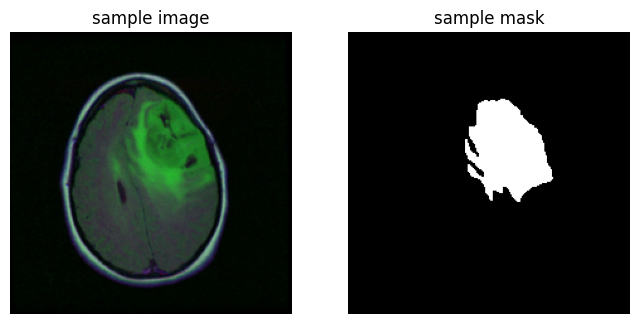

trainable params: 23,937,665
Epoch 1/50
----------------------------------------
train Loss: 0.2658 | IoU: 0.4777 | Dice: 0.6097
valid Loss: 0.3461 | IoU: 0.3358 | Dice: 0.4440
  -> valid loss improved. early_stop_counter reset to 0

Epoch 2/50
----------------------------------------
train Loss: 0.2310 | IoU: 0.5212 | Dice: 0.6588
valid Loss: 0.3699 | IoU: 0.2936 | Dice: 0.3854
  -> no improvement. early_stop_counter: 1/30

Epoch 3/50
----------------------------------------
train Loss: 0.2304 | IoU: 0.5333 | Dice: 0.6659
valid Loss: 0.2831 | IoU: 0.4409 | Dice: 0.5723
  -> valid loss improved. early_stop_counter reset to 0

Epoch 4/50
----------------------------------------
train Loss: 0.2208 | IoU: 0.5375 | Dice: 0.6723
valid Loss: 0.3393 | IoU: 0.3647 | Dice: 0.4806
  -> no improvement. early_stop_counter: 1/30

Epoch 5/50
----------------------------------------
train Loss: 0.2269 | IoU: 0.5281 | Dice: 0.6631
valid Loss: 0.2635 | IoU: 0.5031 | Dice: 0.6369
  -> valid loss improve

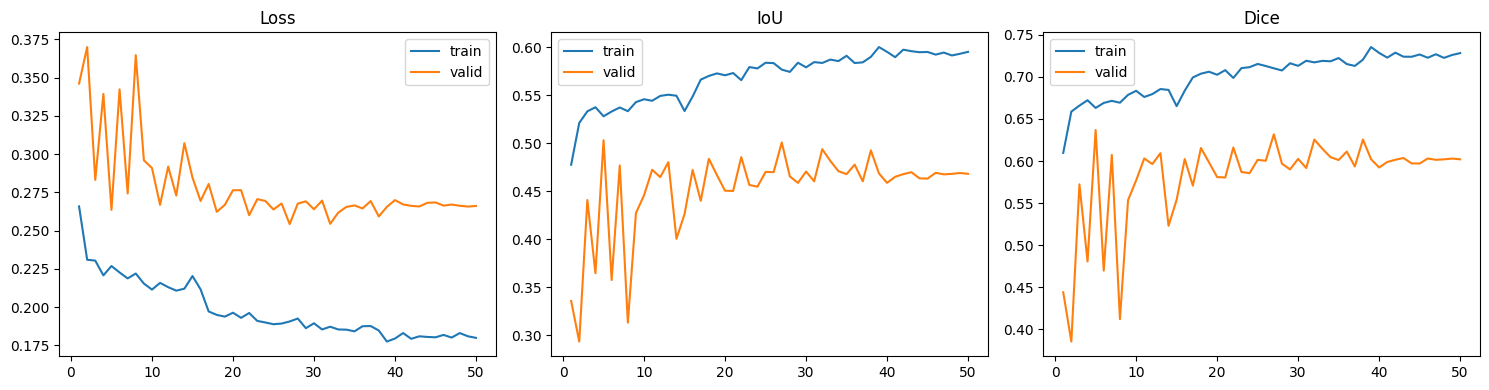

history plot saved to: /content/drive/MyDrive/Colab Notebooks/3-2 deep-learning/hw4_vgg19_dice_bce/vgg19_adam_flip_rotate_dice_bce_history.png
model saved to: /content/drive/MyDrive/Colab Notebooks/3-2 deep-learning/hw4_vgg19_dice_bce/vgg19_adam_flip_rotate_dice_bce.pth
history csv saved to: /content/drive/MyDrive/Colab Notebooks/3-2 deep-learning/hw4_vgg19_dice_bce/vgg19_adam_flip_rotate_dice_bce_history.csv
prediction saved to: /content/drive/MyDrive/Colab Notebooks/3-2 deep-learning/hw4_vgg19_dice_bce/pred_vgg19_dice_bce


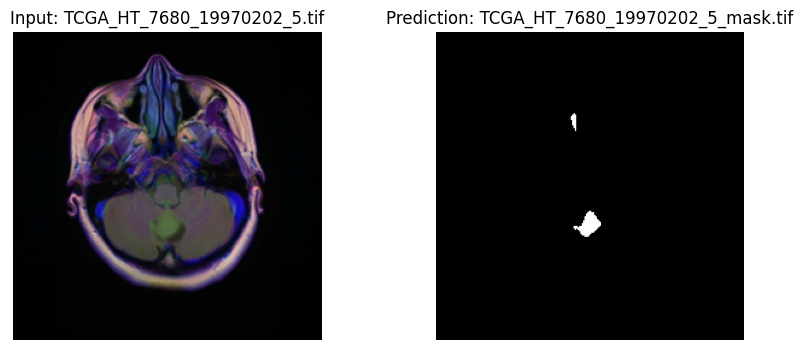

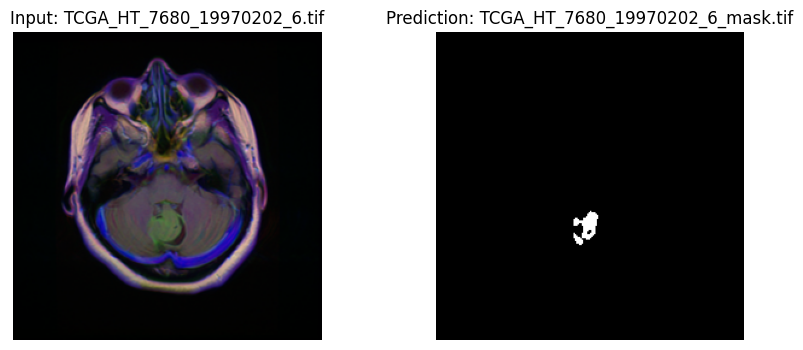

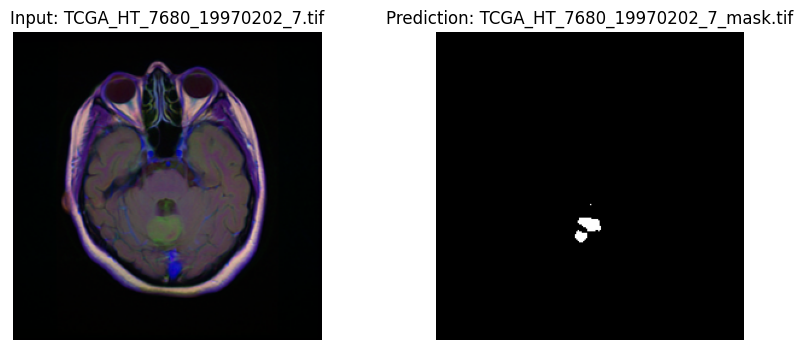

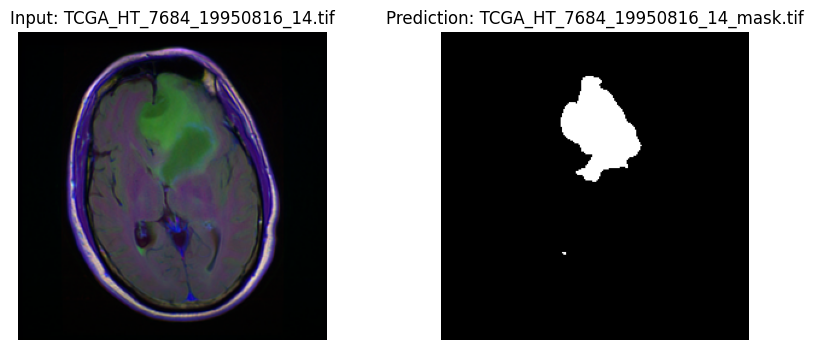

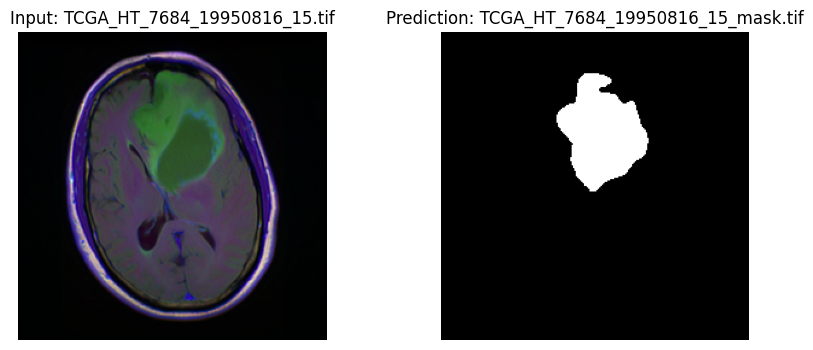

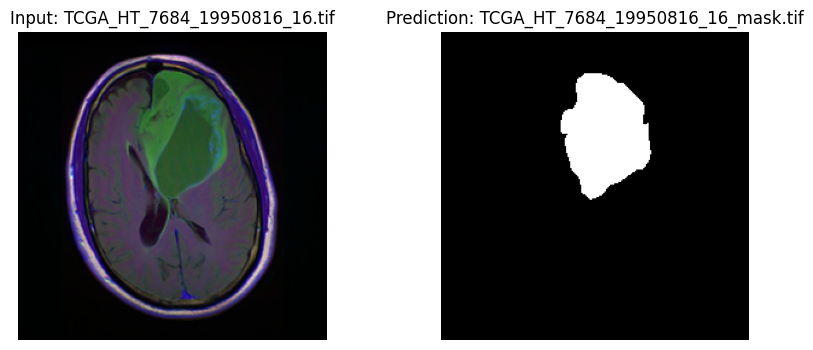

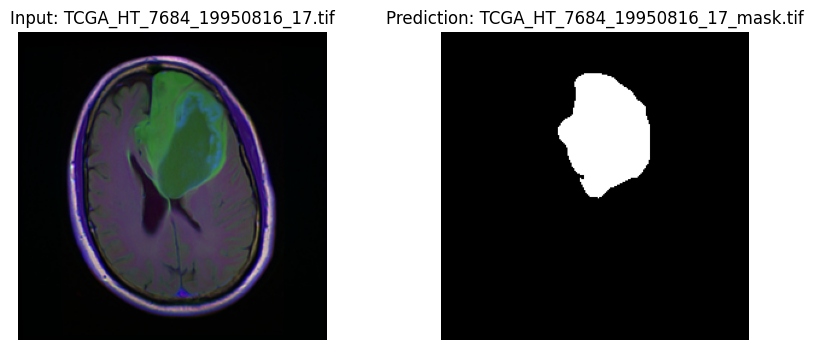

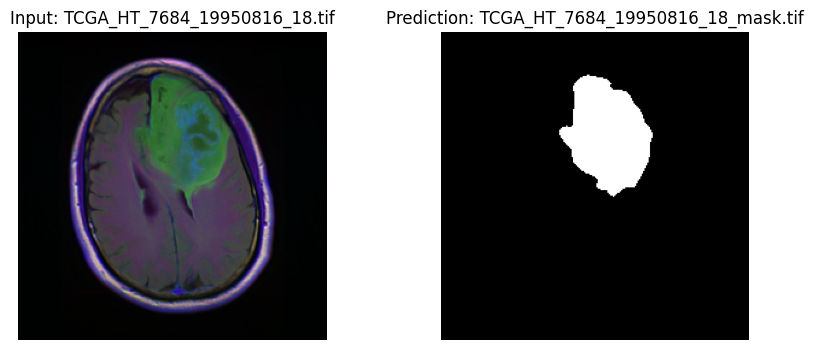

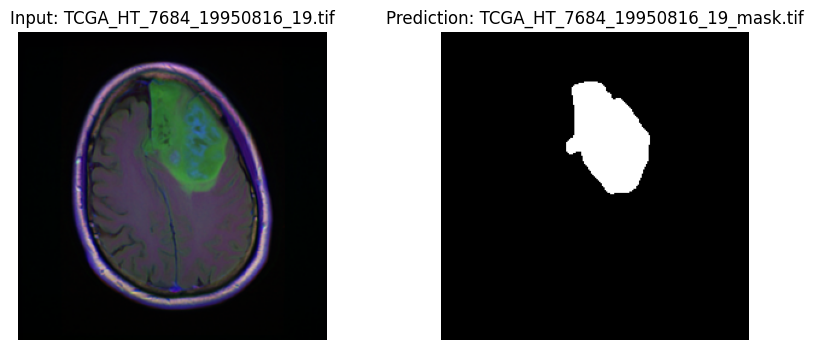

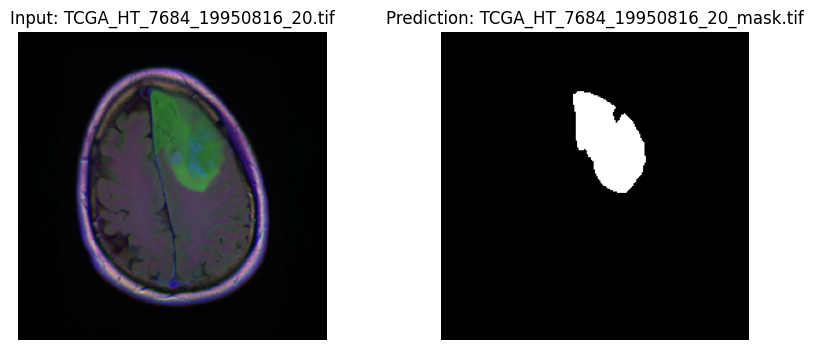


summary_main
{'best_epoch': 27, 'best_valid_loss': 0.25424739903572835, 'best_valid_iou': 0.5009408665472737, 'best_valid_dice': 0.6317185765636866, 'train_time_sec': 1476.6156408786774, 'stopped_early': False}
pred_dir_main: /content/drive/MyDrive/Colab Notebooks/3-2 deep-learning/hw4_vgg19_dice_bce/pred_vgg19_dice_bce


In [51]:
# =========================================================
# 20. Main Run
# =========================================================
cfg_main = copy.deepcopy(CFG)
cfg_main["use_centercrop"] = False
cfg_main["use_lookahead"] = False
cfg_main["use_concat_aug4"] = False
cfg_main["num_epochs"] = 50
cfg_main["threshold"] = 0.5
cfg_main["prediction_dir_name"] = "pred_vgg19_dice_bce"
cfg_main["early_stop_patience"] = 30
cfg_main["min_delta"] = 1e-4

model_main, history_main, loader_test_main, pred_dir_main, summary_main = run_experiment(
    cfg=cfg_main,
    tag="vgg19_adam_flip_rotate_dice_bce"
)

print("\nsummary_main")
print(summary_main)
rint("pred_dir_main:", pred_dir_main)p

In [ ]:
def display_predictions(input_dir, prediction_dir, num_samples=None):
    input_images = sorted([f for f in os.listdir(input_dir) if f.endswith(".tif") and not f.endswith("_mask.tif")])
    prediction_images = sorted([f for f in os.listdir(prediction_dir) if f.endswith(".tif")])

    total = min(len(input_images), len(prediction_images))

    # 👉 핵심
    if num_samples is None:
        num_samples = total

    for i in range(min(num_samples, total)):
        input_path = os.path.join(input_dir, input_images[i])
        pred_path = os.path.join(prediction_dir, prediction_images[i])

        input_image = Image.open(input_path).convert("RGB")
        predicted_mask = Image.open(pred_path)

        plt.figure(figsize=(10, 4))

        plt.subplot(1, 2, 1)
        plt.imshow(input_image)
        plt.title(f"Input: {input_images[i]}")
        plt.axis("off")

        plt.subplot(1, 2, 2)
        plt.imshow(predicted_mask, cmap="gray")
        plt.title(f"Prediction: {prediction_images[i]}")
        plt.axis("off")

        plt.show()

In [ ]:
pred_dir="/content/drive/MyDrive/Colab Notebooks/3-2 deep-learning/hw4_resnet18_before_data_analysis/pred_resnet18_adam"
display_predictions(test_dir, pred_dir, num_samples=None)